In [1]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/abalone.csv'

df = pd.read_csv(path)

df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex_encoded'] = le.fit_transform(df['Sex'])
df = df.drop(['id','Sex'], axis=1)

df.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_encoded
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,2
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,2
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,2
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,1


In [3]:
y=df['Rings']
y.value_counts()

,count
Rings,
9,689
10,634
8,568
11,487
7,391
12,267
6,259
13,203
14,126


In [4]:
X=df.drop('Rings',axis=1)
X.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_encoded
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,2
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,2
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,2
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,1


In [5]:
Y = y.values
X = X.values

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [7]:
#Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
#Defining the model

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

model = Sequential()

model.add(Dense(8,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))

model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,303 (5.09 KB)

 Trainable params: 1,303 (5.09 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model_history = model.fit(x=X_train, y=y_train, epochs=30, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 69.7423 - mse: 69.7423 - val_loss: 25.1813 - val_mse: 25.1813
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 22.6337 - mse: 22.6337 - val_loss: 12.1340 - val_mse: 12.1340
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.8350 - mse: 12.8350 - val_loss: 7.1998 - val_mse: 7.1998
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.5358 - mse: 9.5358 - val_loss: 6.7000 - val_mse: 6.7000
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.3710 - mse: 8.3710 - val_loss: 6.2933 - val_mse: 6.2933
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.5514 - mse: 7.5514 - val_loss: 5.9900 - val_mse: 5.9900
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9728 - mse: 6.9728 - val_loss: 5.8215 - val_mse: 5.8215
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5038 - mse: 6.5038 - val_loss: 5.6967 - val_mse: 5.6967
Epoch 9/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

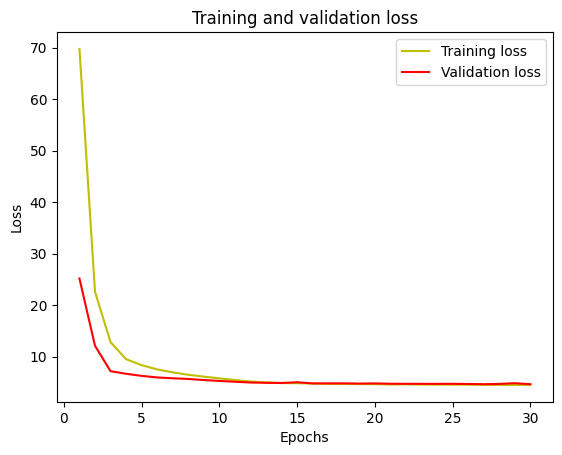

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
#MSE,MAE,R2 of the predicted values
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 4.672875881195068
MAE: 1.5315642356872559
R2: 0.5697290897369385


In [12]:
model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.6729 - mse: 4.6729


[4.672875881195068, 4.672875881195068]